# XGBoost — Traffic Flow Forecasting

This notebook trains and tunes an **XGBoost Regressor** model to predict hourly traffic flow (`FLOW`).

### Notebook Structure
1. Data Loading & Preprocessing
2. Feature Engineering (Hourly aggregation, Cyclical encoding, Lag features)
3. Feature Selection for XGBoost
4. Train / Test Split (Temporal)
5. Baseline XGBoost Model (No Scaling Needed)
6. Hyperparameter Tuning (Optuna Bayesian Search)
7. Final Model Evaluation (Overall + Subgroup)
8. Feature Importance Analysis

> **Why no scaling?** XGBoost is a tree-based model that uses rank-based splits — it is inherently
> scale-invariant. Scaling features will not change the model's predictions.

## 1. Data Loading & Preprocessing

In [1]:
import polars as pl
import numpy as np
# Load the cleaned master CSV
df = pl.read_csv(
    "c:\\Users\\Afsar003\\Desktop\\FYP\\cleaned_master_v2.csv",
    schema_overrides={"SITEREF": pl.String, "SH": pl.String}
)
display(df.head())

DATETIME,UNIQUE_ID,FLOW,SITEREF,REGION,SH,LANE,EXTREME_HAZARD,EXTREME_ID,IS_EXTREME,IS_HOLIDAY,HOLIDAY_NAME,TEMP,RH,WDSP,DEWP,VISIB,GUST,HOUR,DAY_OF_WEEK,MONTH,YEAR,IS_PANDEMIC
str,str,f64,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64
"""2013-04-11T00:00:00.000000""","""01600024_1""",13.0,"""01600024""","""02 - Auckland""","""16""","""Both""","""None""","""None""",0,0,"""None""",13.722222,76.397802,5.967504,9.388889,9.9758,17.49096,0,4,4,2013,0
"""2013-04-11T00:00:00.000000""","""01600024_2""",5.0,"""01600024""","""02 - Auckland""","""16""","""Both""","""None""","""None""",0,0,"""None""",13.722222,76.397802,5.967504,9.388889,9.9758,17.49096,0,4,4,2013,0
"""2013-04-11T00:15:00.000000""","""01600024_1""",9.0,"""01600024""","""02 - Auckland""","""16""","""Both""","""None""","""None""",0,0,"""None""",13.722222,76.397802,5.967504,9.388889,9.9758,17.49096,0,4,4,2013,0
"""2013-04-11T00:15:00.000000""","""01600024_2""",5.0,"""01600024""","""02 - Auckland""","""16""","""Both""","""None""","""None""",0,0,"""None""",13.722222,76.397802,5.967504,9.388889,9.9758,17.49096,0,4,4,2013,0
"""2013-04-11T00:30:00.000000""","""01600024_1""",10.0,"""01600024""","""02 - Auckland""","""16""","""Both""","""None""","""None""",0,0,"""None""",13.722222,76.397802,5.967504,9.388889,9.9758,17.49096,0,4,4,2013,0


In [8]:
DFG = df.group_by("REGION").agg(pl.col("UNIQUE_ID"))

In [2]:
# Parse DATETIME and extract time features
df = df.with_columns(
    pl.col("DATETIME").str.to_datetime()
)

df = df.with_columns([
    pl.col("DATETIME").dt.hour().alias("HOUR"),
    pl.col("DATETIME").dt.weekday().alias("DAY_OF_WEEK"),
    pl.col("DATETIME").dt.month().alias("MONTH"),
    pl.col("DATETIME").dt.year().alias("YEAR")
])

# Encode traffic direction from UNIQUE_ID suffix (_1 or _2)
df = df.with_columns(
    pl.when(pl.col('UNIQUE_ID').str.ends_with('_2'))
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .cast(pl.Int8)
    .alias('IS_DIRECTION_2')
)
print("Raw data shape:", df.shape)

Raw data shape: (5121798, 24)


## 2. Feature Engineering

In [3]:
# Aggregate 15-min records to hourly
df = df.with_columns(
    pl.col('DATETIME').dt.truncate('1h').alias('DATETIME_HOUR')
)

df_hourly = df.group_by(['DATETIME_HOUR', 'UNIQUE_ID', 'SITEREF']).agg([
    pl.col('FLOW').sum().alias('FLOW'),
    pl.col('TEMP').mean(),
    pl.col('RH').mean(),
    pl.col('WDSP').mean(),
    pl.col('DEWP').mean(),
    pl.col('VISIB').mean(),
    pl.col('GUST').mean(),
    pl.col('IS_EXTREME').max(),
    pl.col('IS_HOLIDAY').max(),
    pl.col('LOCKDOWN_L4_AUCKLAND', 'LOCKDOWN_L3_AUCKLAND', 'LOCKDOWN_L4_NATIONAL', 'LOCKDOWN_L3_NATIONAL', 'LOCKDOWN_L2_NATIONAL', 'EVENT_Lockdown_Announced').max(),
    pl.col('IS_DIRECTION_2').max(),
    pl.col('EXTREME_HAZARD').first(),
    pl.col('EXTREME_ID').first(),
    pl.col('HOLIDAY_NAME').first(),
    pl.col('HOUR').first(),
    pl.col('DAY_OF_WEEK').first(),
    pl.col('MONTH').first(),
    pl.col('YEAR').first(),
    pl.col('REGION').first(),
    pl.col('SH').first(),
    pl.col('LANE').first(),
]).sort(['UNIQUE_ID', 'DATETIME_HOUR'])

print(f"Hourly rows: {len(df_hourly):,}")

Hourly rows: 1,279,848


In [4]:
# IS_WEEKEND flag (6=Sat, 7=Sun)
df_hourly = df_hourly.with_columns(
    pl.when(pl.col('DAY_OF_WEEK') >= 6)
    .then(1).otherwise(0)
    .alias('IS_WEEKEND')
)

# Region one-hot flags
df_hourly = df_hourly.with_columns(
    pl.col('REGION').str.replace(r'^\d+ - ', '').alias('REGION_NAME')
).with_columns([
    (pl.col('REGION_NAME') == 'Auckland').cast(pl.Int8).alias('IS_AUCKLAND'),
    (pl.col('REGION_NAME') == 'Wellington').cast(pl.Int8).alias('IS_WELLINGTON'),
    (pl.col('REGION_NAME') == 'Canterbury').cast(pl.Int8).alias('IS_CANTERBURY'),
])

# Holiday and Extreme Event one-hot encoding
unique_holidays = (
    df.filter((pl.col('IS_HOLIDAY') == 1) & (pl.col('HOLIDAY_NAME').is_not_null()) & (pl.col('HOLIDAY_NAME') != 'None'))
    ['HOLIDAY_NAME'].unique().to_list()
)
unique_extremes = (
    df.filter((pl.col('IS_EXTREME') == 1) & (pl.col('EXTREME_HAZARD') != 'None'))
    ['EXTREME_HAZARD'].unique().to_list()
)

one_hot_exprs = []
for holiday in unique_holidays:
    clean_name = holiday.replace(" ", "_").replace("'", "")
    one_hot_exprs.append(
        pl.when((pl.col('IS_HOLIDAY') == 1) & (pl.col('HOLIDAY_NAME') == holiday))
        .then(1).otherwise(0).alias(f'HOLIDAY_{clean_name}')
    )
for extreme_id in unique_extremes:
    one_hot_exprs.append(
        pl.when((pl.col('IS_EXTREME') == 1) & (pl.col('EXTREME_HAZARD') == extreme_id))
        .then(1).otherwise(0).alias(f'EVENT_{extreme_id}')
    )

df_hourly = df_hourly.with_columns(one_hot_exprs)
print(f"Created {len(unique_holidays)} holiday columns and {len(unique_extremes)} extreme event columns.")

Created 10 holiday columns and 5 extreme event columns.


In [5]:
# Cyclical time encoding (useful even for tree models — captures periodicity)
df_hourly = df_hourly.with_columns([
    (2 * np.pi * pl.col("HOUR") / 24).sin().alias("HOUR_SIN"),
    (2 * np.pi * pl.col("HOUR") / 24).cos().alias("HOUR_COS"),
    (2 * np.pi * pl.col("DAY_OF_WEEK") / 7).sin().alias("DAY_SIN"),
    (2 * np.pi * pl.col("DAY_OF_WEEK") / 7).cos().alias("DAY_COS"),
    (2 * np.pi * pl.col("MONTH") / 12).sin().alias("MONTH_SIN"),
    (2 * np.pi * pl.col("MONTH") / 12).cos().alias("MONTH_COS")
])

# Lag features — XGBoost can exploit all lags including short-term
df_hourly = df_hourly.with_columns([
    pl.col('FLOW').shift(1).over('UNIQUE_ID').alias('FLOW_lag_1h'),
    pl.col('FLOW').shift(24).over('UNIQUE_ID').alias('FLOW_lag_24h'),
    pl.col('FLOW').shift(168).over('UNIQUE_ID').alias('FLOW_lag_168h'),
    pl.col('FLOW').shift(1).rolling_mean(window_size=4).over('UNIQUE_ID').alias('FLOW_roll_mean_4h'),
])

print("Feature engineering complete.")

Feature engineering complete.


## 3. Feature Selection for XGBoost

XGBoost uses all available features including **all lag columns** (`FLOW_lag_1h`, `FLOW_roll_mean_4h`) since tree-based models handle these without linear leakage concerns.

> **Key difference from Linear Regression:** XGBoost includes `FLOW_lag_1h` and `FLOW_roll_mean_4h`
> because gradient boosted trees are non-parametric and model these correctly.

In [6]:
WEATHER_FEATURES  = ['TEMP', 'RH', 'WDSP', 'DEWP', 'VISIB', 'GUST']

NRC_FEATURES = [
    'LOCKDOWN_L4_AUCKLAND', 'LOCKDOWN_L3_AUCKLAND', 'LOCKDOWN_L4_NATIONAL', 'LOCKDOWN_L3_NATIONAL', 'LOCKDOWN_L2_NATIONAL', 'EVENT_Lockdown_Announced', 'IS_WEEKEND',
    'HOLIDAY_ANZAC_Day', 'HOLIDAY_Christmas_Day', 'HOLIDAY_New_Years_Day',
    'HOLIDAY_Boxing_Day', 'HOLIDAY_Waitangi_Day', 'HOLIDAY_Day_after_New_Years_Day',
    'HOLIDAY_Queens_Birthday', 'HOLIDAY_Labour_Day', 'HOLIDAY_Easter_Monday',
    'HOLIDAY_Good_Friday',
    'EVENT_Multi Hazard, Snow / Ice', 'EVENT_High Wind / Gust',
    'EVENT_Multi Hazard', 'EVENT_Snow / Ice', 'EVENT_Flooding',
]

SPECIFIC_REGIONS  = ['IS_AUCKLAND', 'IS_WELLINGTON', 'IS_CANTERBURY']

TIME_FEATURES     = ['HOUR_SIN', 'HOUR_COS', 'DAY_SIN', 'DAY_COS', 'MONTH_SIN', 'MONTH_COS', 'YEAR']

TRAFFIC_FEATURES  = ['IS_DIRECTION_2']

# XGBoost uses all lag features including short-term
LAG_FEATURES      = ['FLOW_lag_24h']

TARGET = ['FLOW']

ALL_FEATURES = TRAFFIC_FEATURES + NRC_FEATURES + SPECIFIC_REGIONS + TIME_FEATURES + WEATHER_FEATURES + LAG_FEATURES
print(f"Total features: {len(ALL_FEATURES)}")
print(ALL_FEATURES)

Total features: 35
['IS_DIRECTION_2', 'IS_PANDEMIC', 'IS_WEEKEND', 'HOLIDAY_ANZAC_Day', 'HOLIDAY_Christmas_Day', 'HOLIDAY_New_Years_Day', 'HOLIDAY_Boxing_Day', 'HOLIDAY_Waitangi_Day', 'HOLIDAY_Day_after_New_Years_Day', 'HOLIDAY_Queens_Birthday', 'HOLIDAY_Labour_Day', 'HOLIDAY_Easter_Monday', 'HOLIDAY_Good_Friday', 'EVENT_Multi Hazard, Snow / Ice', 'EVENT_High Wind / Gust', 'EVENT_Multi Hazard', 'EVENT_Snow / Ice', 'EVENT_Flooding', 'IS_AUCKLAND', 'IS_WELLINGTON', 'IS_CANTERBURY', 'HOUR_SIN', 'HOUR_COS', 'DAY_SIN', 'DAY_COS', 'MONTH_SIN', 'MONTH_COS', 'YEAR', 'TEMP', 'RH', 'WDSP', 'DEWP', 'VISIB', 'GUST', 'FLOW_lag_24h']


## 4. Train / Test Split (Temporal)

- **Train**: 2018–2020
- **Test**: 2021

In [7]:
import pandas as pd

# Drop null rows (from lag windows at start of each series)
df_hourly = df_hourly.drop_nulls(subset=ALL_FEATURES)

train = df_hourly.filter(pl.col('YEAR').is_in([2018, 2019, 2020]))
test  = df_hourly.filter(pl.col('YEAR') == 2021)

train = train.to_pandas()
test  = test.to_pandas()

train = train.sort_values('DATETIME_HOUR')
X_train, y_train = train[ALL_FEATURES], train[TARGET].values.ravel()
X_test,  y_test  = test[ALL_FEATURES],  test[TARGET].values.ravel()

print(f"Train: {len(X_train):,} rows (2018–2020)")
print(f"Test:  {len(X_test):,} rows (2021)")

Train: 551,716 rows (2018–2020)
Test:  145,712 rows (2021)


## 5. Baseline XGBoost Model

No feature scaling is needed — XGBoost is scale-invariant by design.

In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def print_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:<12} | MAE: {mae:>8.2f} vph | RMSE: {rmse:>8.2f} vph | R²: {r2:.4f}")

baseline_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',   # Fast histogram-based method
    n_jobs=-1
)
baseline_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

y_pred_train = baseline_xgb.predict(X_train)
y_pred_test  = baseline_xgb.predict(X_test)

print(f"\n{'Split':<12} | {'MAE':>12} | {'RMSE':>13} | {'R²':>6}  | 24 hour lag only")
print("-" * 55)
print_metrics(y_train, y_pred_train, 'TRAIN')
print_metrics(y_test,  y_pred_test,  'TEST')

[0]	validation_0-rmse:710.92167
[100]	validation_0-rmse:186.61290
[199]	validation_0-rmse:181.16829

Split        |          MAE |          RMSE |     R²  | 24 hour lag only
-------------------------------------------------------
TRAIN        | MAE:    86.99 vph | RMSE:   163.61 vph | R²: 0.9544
TEST         | MAE:    94.98 vph | RMSE:   181.17 vph | R²: 0.9403


# RandomizedSearch tuning

In [34]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform
from xgboost import XGBRegressor

# 1. Define distributions centered around your Block 20 Baseline
param_dist = {
    # Baseline was 200. We'll search between 100 and 350.
    'n_estimators': randint(100, 350),       
    
    # Baseline was 0.05. We'll search between 0.01 and 0.10.
    'learning_rate': uniform(0.01, 0.09),    
    
    # Baseline was 6. We'll search slightly shallower and deeper.
    'max_depth': randint(4, 9),              
    
    # Baseline was 0.8. We'll search from 0.6 to 1.0.
    'subsample': uniform(0.6, 0.4),          
    'colsample_bytree': uniform(0.6, 0.4),   
    
    # Adding a bit of regularization to prevent overfitting
    'min_child_weight': randint(1, 8)
}

# 2. Time-Series aware cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# 3. Base model setup (keeping it fast with 'hist')
base_xgb = XGBRegressor(
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

# 4. Initialize Randomized Search
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=50,                              # Number of parameter settings that are sampled
    scoring='neg_root_mean_squared_error',  # Optimize specifically for RMSE
    cv=tscv,                                # Respect temporal order
    verbose=2,
    random_state=42,
    n_jobs=-1                               # Run cross-validation folds in parallel
)

# 5. Execute the search
print("Starting Randomized Search...")
random_search.fit(X_train, y_train)

# 6. View the results
best_model = random_search.best_estimator_
print("-" * 55)
print(f"Best CV RMSE: {-random_search.best_score_:.2f} vph")
print("Best Parameters found:")
for key, value in random_search.best_params_.items():
    print(f"  {key}: {value}")

Starting Randomized Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.09556428757689245, max_depth=6, min_child_weight=5, n_estimators=120, subsample=0.6624074561769746; total time=   3.1s
[CV] END colsample_bytree=0.749816047538945, learning_rate=0.09556428757689245, max_depth=6, min_child_weight=5, n_estimators=120, subsample=0.6624074561769746; total time=  13.6s
[CV] END colsample_bytree=0.662397808134481, learning_rate=0.015227525095137952, max_depth=8, min_child_weight=4, n_estimators=203, subsample=0.8832290311184181; total time=  31.4s
[CV] END colsample_bytree=0.996884623716487, learning_rate=0.06557333586649448, max_depth=5, min_child_weight=6, n_estimators=335, subsample=0.6092249700165663; total time=  17.6s
[CV] END colsample_bytree=0.8099098641033556, learning_rate=0.04598748745437299, max_depth=7, min_child_weight=4, n_estimators=307, subsample=0.6931085361721216; total time=  14.1s
[CV] E

In [44]:
# Train final model with best hyperparameters
# 1. Extract the best parameters from your search
best_params = random_search.best_params_

# 2. Build a new model using those parameters, but ADD early stopping
tuned_xgb = XGBRegressor(
    **best_params,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30 # <--- The Magic Fix
)

# 3. Fit the model (it will stop automatically when Test RMSE goes up)
print("=== FINAL XGBoost MODEL ===")
tuned_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# 4. Predict and evaluate
y_pred_train_final = final_xgb.predict(X_train)
y_pred_test_final = final_xgb.predict(X_test)

print("-" * 55)
print(f"{'Split':<12} | {'MAE':>12} | {'RMSE':>13} | {'R²':>6}")
print("-" * 55)
print_metrics(y_train, y_pred_train_final, 'TRAIN')
print_metrics(y_test, y_pred_test_final, 'TEST')

=== FINAL XGBoost MODEL ===
[0]	validation_0-rmse:693.67998
[50]	validation_0-rmse:181.69208
[100]	validation_0-rmse:177.96685
[105]	validation_0-rmse:178.14775
-------------------------------------------------------
Split        |          MAE |          RMSE |     R²
-------------------------------------------------------
TRAIN        | MAE:    81.04 vph | RMSE:   153.48 vph | R²: 0.9599
TEST         | MAE:    92.58 vph | RMSE:   176.45 vph | R²: 0.9434


In [46]:
import joblib

# 1. Save the model to a file
joblib.dump(tuned_xgb, 'tuned_xgb.joblib')

['tuned_xgb.joblib']

Top 20 most important features:


,feature,importance
34,FLOW_lag_24h,0.542187
22,HOUR_COS,0.088808
19,IS_WELLINGTON,0.069459
2,IS_WEEKEND,0.054144
20,IS_CANTERBURY,0.030717
18,IS_AUCKLAND,0.024933
21,HOUR_SIN,0.024027
0,IS_DIRECTION_2,0.022496
24,DAY_COS,0.020837
23,DAY_SIN,0.015339


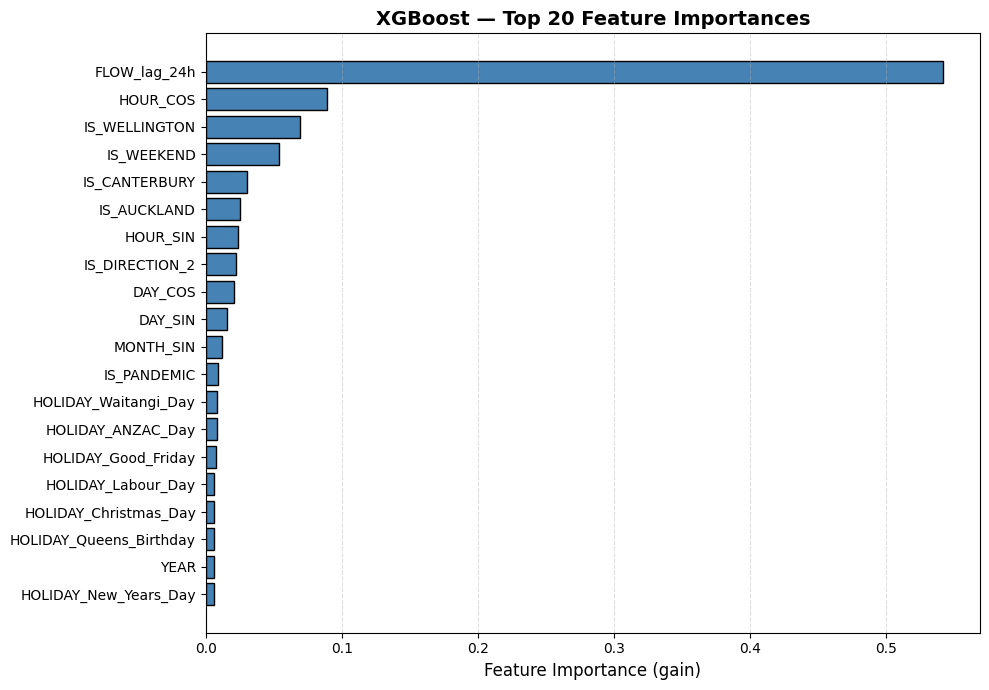

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance from the final model
imp_df = pd.DataFrame({
    'feature':    ALL_FEATURES,
    'importance': tuned_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 most important features:")
display(imp_df.head(20))

# Plot top 20
top20 = imp_df.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Feature Importance (gain)', fontsize=12)
ax.set_title('XGBoost — Top 20 Feature Importances', fontsize=14, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Subgroup evaluation on test set
eval_df = test.copy()
eval_df['Actual_Flow']    = y_test
eval_df['Predicted_Flow'] = y_pred_test_final

holiday_cols = [
    'HOLIDAY_ANZAC_Day', 'HOLIDAY_Christmas_Day', 'HOLIDAY_New_Years_Day',
    'HOLIDAY_Boxing_Day', 'HOLIDAY_Waitangi_Day', 'HOLIDAY_Day_after_New_Years_Day',
    'HOLIDAY_Queens_Birthday', 'HOLIDAY_Labour_Day', 'HOLIDAY_Easter_Monday', 'HOLIDAY_Good_Friday'
]
hazard_cols = [
    'EVENT_Multi Hazard, Snow / Ice', 'EVENT_High Wind / Gust',
    'EVENT_Multi Hazard', 'EVENT_Snow / Ice', 'EVENT_Flooding'
]
eval_df['Any_Holiday'] = eval_df[holiday_cols].max(axis=1)
eval_df['Any_Hazard']  = eval_df[hazard_cols].max(axis=1)

extreme_gust_threshold      = np.percentile(train['GUST'], 95)
extreme_visib_threshold     = np.percentile(train['VISIB'], 5)
extreme_HIGH_temp_threshold = np.percentile(train['TEMP'], 95)
extreme_LOW_temp_threshold  = np.percentile(train['TEMP'], 5)
extreme_rh_threshold        = np.percentile(train['RH'], 95)
extreme_wdsp_threshold      = np.percentile(train['WDSP'], 95)

def subgroup_metrics(df, mask, name):
    subset = df[mask]
    if len(subset) < 2:
        print(f"{name:<28} | Not enough data.")
        return
    mae  = mean_absolute_error(subset['Actual_Flow'], subset['Predicted_Flow'])
    rmse = np.sqrt(mean_squared_error(subset['Actual_Flow'], subset['Predicted_Flow']))
    r2   = r2_score(subset['Actual_Flow'], subset['Predicted_Flow'])
    print(f"{name:<28} | MAE: {mae:>6.2f} | RMSE: {rmse:>7.2f} | R²: {r2:>6.4f}  (n={len(subset):,})")

print("=== SUBGROUP EVALUATION (TEST SET 2021) ===")
print("-" * 80)
subgroup_metrics(eval_df, eval_df['IS_WEEKEND'] == 1,                     "Weekends")
subgroup_metrics(eval_df, eval_df['Any_Holiday'] == 1,                    "All Holidays")
subgroup_metrics(eval_df, eval_df['Any_Hazard'] == 1,                     "All Hazard Events")
subgroup_metrics(eval_df, eval_df['LOCKDOWN_L4_AUCKLAND', 'LOCKDOWN_L3_AUCKLAND', 'LOCKDOWN_L4_NATIONAL', 'LOCKDOWN_L3_NATIONAL', 'LOCKDOWN_L2_NATIONAL', 'EVENT_Lockdown_Announced'] == 1,                    "Pandemic Period")
subgroup_metrics(eval_df, eval_df['GUST'] > extreme_gust_threshold,       "Extreme Wind Gusts")
subgroup_metrics(eval_df, eval_df['VISIB'] < extreme_visib_threshold,     "Poor Visibility")
subgroup_metrics(eval_df, eval_df['TEMP'] > extreme_HIGH_temp_threshold,  "High Temperature")
subgroup_metrics(eval_df, eval_df['TEMP'] < extreme_LOW_temp_threshold,   "Low Temperature")
subgroup_metrics(eval_df, eval_df['RH'] > extreme_rh_threshold,           "High Humidity")
subgroup_metrics(eval_df, eval_df['WDSP'] > extreme_wdsp_threshold,       "Increased Wind Speed")

## 8. Feature Importance Analysis

In [ ]:
import joblib
tuned_xgboost = joblib.load('C:\\Users\\Afsar003\\.gemini\\antigravity\\scratch\\traffic_app\\tuned_xgb (1).joblib')

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# SHAP values for model explainability (optional — requires shap library)
import shap
explainer = shap.TreeExplainer(tuned_xgboost)
shap_values = explainer.shap_values(X_test)   # Subset for speed
#shap.summary_plot(shap_values, X_test, feature_names=ALL_FEATURES)


NameError: name 'X_test' is not defined